# 📊 Báo Cáo Phân Tích Dữ Liệu Khám Phá (EDA): Tập Dữ Liệu ASSISTments 2017

Notebook này trình bày báo cáo phân tích dữ liệu khám phá (Exploratory Data Analysis - EDA) cho tập dữ liệu **ASSISTments 2017 Competition Dataset** trong bài toán **Knowledge Tracing (Theo vết kiến thức)**.

### 📌 Mục Tiêu Phân Tích:
1. **Kiểm tra chất lượng dữ liệu**: Đánh giá tính đầy đủ (missing values), sự trùng lặp (duplicates), và thứ tự thời gian (temporal ordering).
2. **Phân tích tương tác học sinh (Student Level)**: Khám phá phân bố chuỗi tương tác của học sinh để xác định chiến lược padding/truncation chuỗi.
3. **Phân tích kỹ năng (Skill Level)**: Thống kê tần suất xuất hiện và mức độ mất cân bằng (imbalance) giữa 102 kỹ năng.
4. **Phân tích hành vi & phản hồi (Behavioral Metrics)**: Nghiên cứu thời gian làm bài (`timeTaken`), tần suất sử dụng gợi ý (`hintCount`) và độ khó của kỹ năng (correct rate).
5. **Đề xuất tiền xử lý dữ liệu (Feature Engineering)**: Đưa ra các khuyến nghị tối ưu hóa dữ liệu đầu vào cho các mô hình Knowledge Tracing như DKT, SAKT, SAINT.

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image, HTML

# Đường dẫn tương đối (vì notebook nằm trong thư mục notebooks/)
NOTEBOOK_DIR = Path('.').resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
REPORT_PATH = OUTPUT_DIR / 'reports' / 'eda_assistments.json'
FALLBACK_REPORT_PATH = OUTPUT_DIR / 'reports' / 'eda_summary.json'
FIGURES_DIR = OUTPUT_DIR / 'figures' / 'eda'

print(f"📂 Thư mục báo cáo: {REPORT_PATH.parent.absolute()}")
print(f"🖼️ Thư mục hình ảnh: {FIGURES_DIR.absolute()}")

📂 Thư mục báo cáo: /Users/baonguyen/DEV/graduate/kt-research/outputs/reports
🖼️ Thư mục hình ảnh: /Users/baonguyen/DEV/graduate/kt-research/outputs/figures/eda


---
## 1. 📑 Thống Kê Tổng Quan Về Tập Dữ Liệu (Dataset Overview Metrics)

Tập dữ liệu ASSISTments 2017 chứa thông tin chi tiết về quá trình giải bài tập toán trực tuyến của học sinh trung học. Báo cáo dưới đây được tổng hợp tự động từ module `src.data.eda` và script `scripts/eda_assistments.py`.

In [2]:
# Tải dữ liệu báo cáo EDA
report = None
if REPORT_PATH.exists():
    with open(REPORT_PATH, 'r', encoding='utf-8') as f:
        report = json.load(f)
elif FALLBACK_REPORT_PATH.exists():
    with open(FALLBACK_REPORT_PATH, 'r', encoding='utf-8') as f:
        report = json.load(f)
else:
    print("⚠️ Không tìm thấy file JSON report.")

if report:
    summary_data = [
        {"Hạng mục Metric": "Tổng số dòng (Interactions)", "Giá trị": f"{report.get('n_rows', 0):,}", "Ghi chú": "Tổng số sự kiện tương tác bài tập"},
        {"Hạng mục Metric": "Số học sinh (Unique Students)", "Giá trị": f"{report.get('n_students', 0):,}", "Ghi chú": "Số lượng học sinh duy nhất trong tập dữ liệu"},
        {"Hạng mục Metric": "Số kỹ năng (Unique Skills)", "Giá trị": f"{report.get('n_skills', 0):,}", "Ghi chú": "Số lượng khái niệm toán học (skill/KC)"},
        {"Hạng mục Metric": "Tỷ lệ trả lời đúng (Correct Rate)", "Giá trị": f"{report.get('correct_rate', 0)*100:.2f}%", "Ghi chú": "Tỷ lệ câu trả lời đúng trên toàn tập dữ liệu"},
        {"Hạng mục Metric": "Số dòng thiếu (Missing Rows)", "Giá trị": f"{report.get('missing_required_rows', 0)}", "Ghi chú": "Dữ liệu hoàn toàn sạch trên các cột bắt buộc"},
        {"Hạng mục Metric": "Số dòng trùng lặp (Duplicates)", "Giá trị": f"{report.get('duplicate_rows', 0)}", "Ghi chú": "Trùng lặp theo (studentId, problemId, startTime, action_num)"},
        {"Hạng mục Metric": "Số dòng lệch thời gian (Negative Time Diff)", "Giá trị": f"{report.get('negative_time_differences', 0)}", "Ghi chú": "Thứ tự thời gian theo chuỗi của từng học sinh"},
        {"Hạng mục Metric": "Học sinh có < 20 tương tác", "Giá trị": f"{report.get('students_lt_20_interactions', 0)} ({report.get('students_lt_20_interactions', 0)/report.get('n_students', 1)*100:.2f}%)", "Ghi chú": "Tỷ lệ học sinh có chuỗi tương tác quá ngắn"},
        {"Hạng mục Metric": "Kỹ năng có < 20 tương tác", "Giá trị": f"{report.get('skills_lt_20_interactions', 0)} ({report.get('skills_lt_20_interactions', 0)/report.get('n_skills', 1)*100:.2f}%)", "Ghi chú": "Các kỹ năng hiếm xuất hiện (Long-tail skills)"},
    ]
    df_summary = pd.DataFrame(summary_data)
    display(HTML(df_summary.to_html(index=False, classes='table table-striped table-hover', escape=False)))

Hạng mục Metric,Giá trị,Ghi chú
Tổng số dòng (Interactions),"942,816",Tổng số sự kiện tương tác bài tập
Số học sinh (Unique Students),"1,709",Số lượng học sinh duy nhất trong tập dữ liệu
Số kỹ năng (Unique Skills),102,Số lượng khái niệm toán học (skill/KC)
Tỷ lệ trả lời đúng (Correct Rate),37.27%,Tỷ lệ câu trả lời đúng trên toàn tập dữ liệu
Số dòng thiếu (Missing Rows),0,Dữ liệu hoàn toàn sạch trên các cột bắt buộc
Số dòng trùng lặp (Duplicates),0,"Trùng lặp theo (studentId, problemId, startTime, action_num)"
Số dòng lệch thời gian (Negative Time Diff),0,Thứ tự thời gian theo chuỗi của từng học sinh
Học sinh có < 20 tương tác,4 (0.23%),Tỷ lệ học sinh có chuỗi tương tác quá ngắn
Kỹ năng có < 20 tương tác,10 (9.80%),Các kỹ năng hiếm xuất hiện (Long-tail skills)


---
## 2. 👥 Phân Tích Tương Tác Học Sinh (Distribution of Student Interactions)

Mục đích của biểu đồ này là kiểm tra độ dài chuỗi tương tác của học sinh (`studentId`). Độ dài chuỗi tương tác đóng vai trò quyết định trong việc chọn kích thước cửa sổ đầu vào (`max_seq_len`) khi huấn luyện các mô hình RNN/Transformer cho Knowledge Tracing.

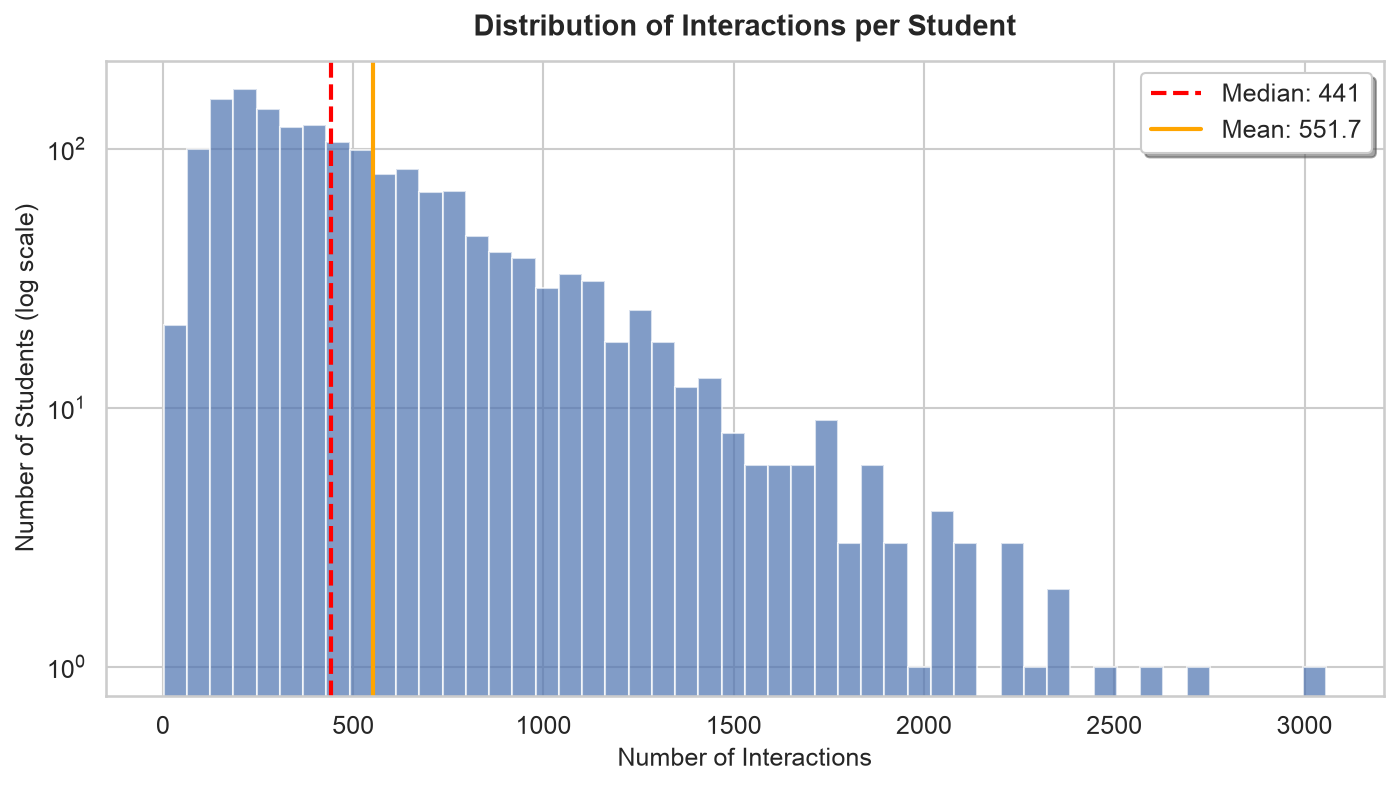

In [3]:
fig1_path = FIGURES_DIR / "01_student_interactions_dist.png"
if fig1_path.exists():
    display(Image(filename=fig1_path, width=800))
else:
    print(f"⚠️ Không tìm thấy biểu đồ tại {fig1_path}")

### 🔍 Phân Tích Chi Tiết Biểu Đồ 01:
- **Trung vị (Median)**: **441 tương tác/học sinh** — 50% số học sinh thực hiện ít nhất 441 bài tập.
- **Trung bình (Mean)**: **551.7 tương tác/học sinh** (cao hơn trung vị do phân bố bị lệch phải bởi một số ít học sinh chăm chỉ có tới 3,057 tương tác).
- **Phạm vi (Range)**: Từ **2** đến **3,057** tương tác.
- **Tương tác ngắn**: Chỉ có **4 học sinh** (< 0.24%) có dưới 20 tương tác, và **1 học sinh** có dưới 10 tương tác.

### 💡 Ý Nghĩa & Đề Xuất Cho Mô Hình Knowledge Tracing:
1. **Chất lượng chuỗi dữ liệu rất cao**: Khác với một số tập dữ liệu KT khác chứa nhiều học sinh "rác" (chỉ làm 1–2 câu rồi bỏ), ASSISTments 2017 có chuỗi tương tác dài và liên tục cho hầu hết học sinh.
2. **Thiết lập Max Sequence Length (`max_seq_len`)**:
   - Với các mô hình như **DKT (LSTM/GRU)** hoặc **SAKT/SAINT (Transformer)**, ngưỡng cắt chuỗi hợp lý là từ **100 đến 200 bước**.
   - Chuỗi dài hơn (vd: >500) có thể áp dụng kỹ thuật **Sliding Window** (cửa sổ trượt) để chia nhỏ thành các chuỗi con mà không làm mất thông tin học tập của học sinh.

---
## 3. 🎯 Phân Tích Tần Suất Kỹ Năng (Top 50 Skills Interaction Count)

Biểu đồ bar chart nằm ngang thể hiện 50 kỹ năng (`skill`) có số lượng lượt tương tác cao nhất trong tổng số 102 kỹ năng của tập dữ liệu.

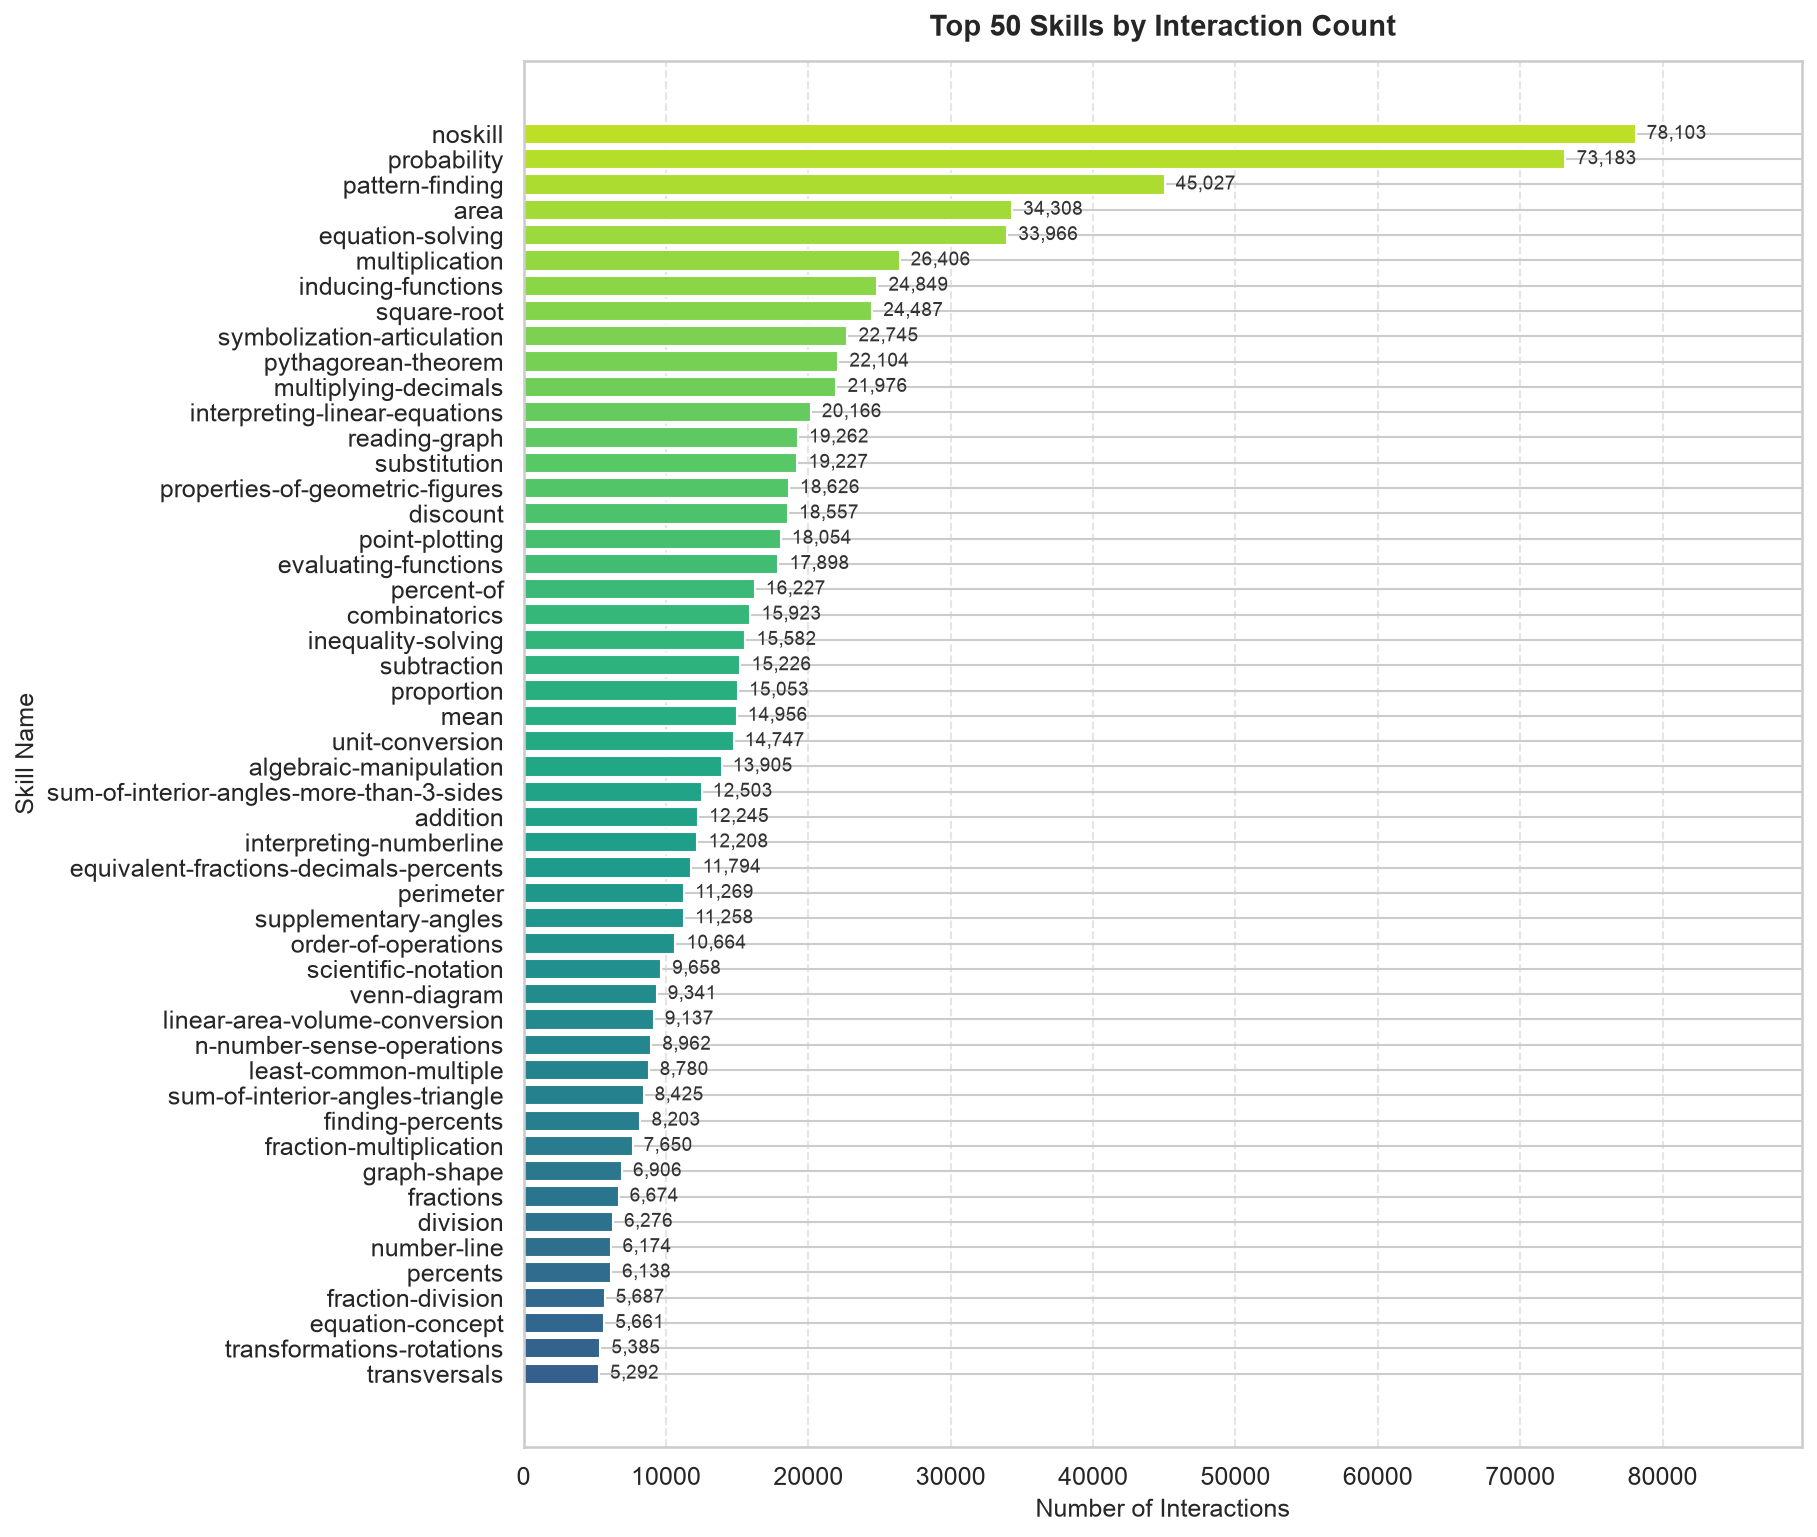

In [4]:
fig2_path = FIGURES_DIR / "02_top_skills_dist.png"
if fig2_path.exists():
    display(Image(filename=fig2_path, width=800))
else:
    print(f"⚠️ Không tìm thấy biểu đồ tại {fig2_path}")

### 🔍 Phân Tích Chi Tiết Biểu Đồ 02:
- **Tổng số kỹ năng**: 102 kỹ năng.
- **Top 5 kỹ năng phổ biến nhất**:
  1. `noskill`: **78,103 tương tác** (chiếm ~8.28% toàn bộ dữ liệu)
  2. `probability`: **73,183 tương tác** (chiếm ~7.76%)
  3. `pattern-finding`: **45,027 tương tác**
  4. `area`: **34,308 tương tác**
  5. `equation-solving`: **33,966 tương tác**
- **Hiệu ứng Long-tail (Đuôi dài)**: Mất cân bằng tần suất nghiêm trọng. 10 kỹ năng ít phổ biến nhất (ví dụ: `application: compare points`, `slope`) chỉ có dưới 20 lượt tương tác.

### 💡 Ý Nghĩa & Đề Xuất Cho Mô Hình Knowledge Tracing:
1. **Xử lý nhãn `noskill`**: Nhãn `noskill` là các bài tập chưa được chuyên gia giáo dục phân loại kỹ năng. Có 2 hướng xử lý:
   - Coi `noskill` là một ID kỹ năng độc lập (khiến mô hình học đặc trưng chung cho dạng bài tập không nhãn).
   - Sử dụng ID bài tập (`problemId`) kết hợp để mô hình vẫn học được nhúng thông tin (Problem-level Embedding).
2. **Xử lý Mất cân bằng (Skill Imbalance)**: Đa số bài tập tập trung vào một số chủ đề chính (Xác suất, Tìm quy luật, Diện tích, Giải phương trình). Cần đánh giá mô hình bằng chỉ số **AUC (Area Under Curve)** trên từng nhóm kỹ năng thay vì chỉ dùng Accuracy tổng thể.

---
## 4. ⏱️ Phân Tích Thời Gian Phản Hồi (Time Taken per Interaction)

Thời gian học sinh suy nghĩ và hoàn thành câu hỏi (`timeTaken` - tính bằng giây) là thông tin quan trọng phản ánh mức độ thành thục (mastery) cũng như trạng thái tâm lý (xao nhãng hay tập trung) của học sinh.

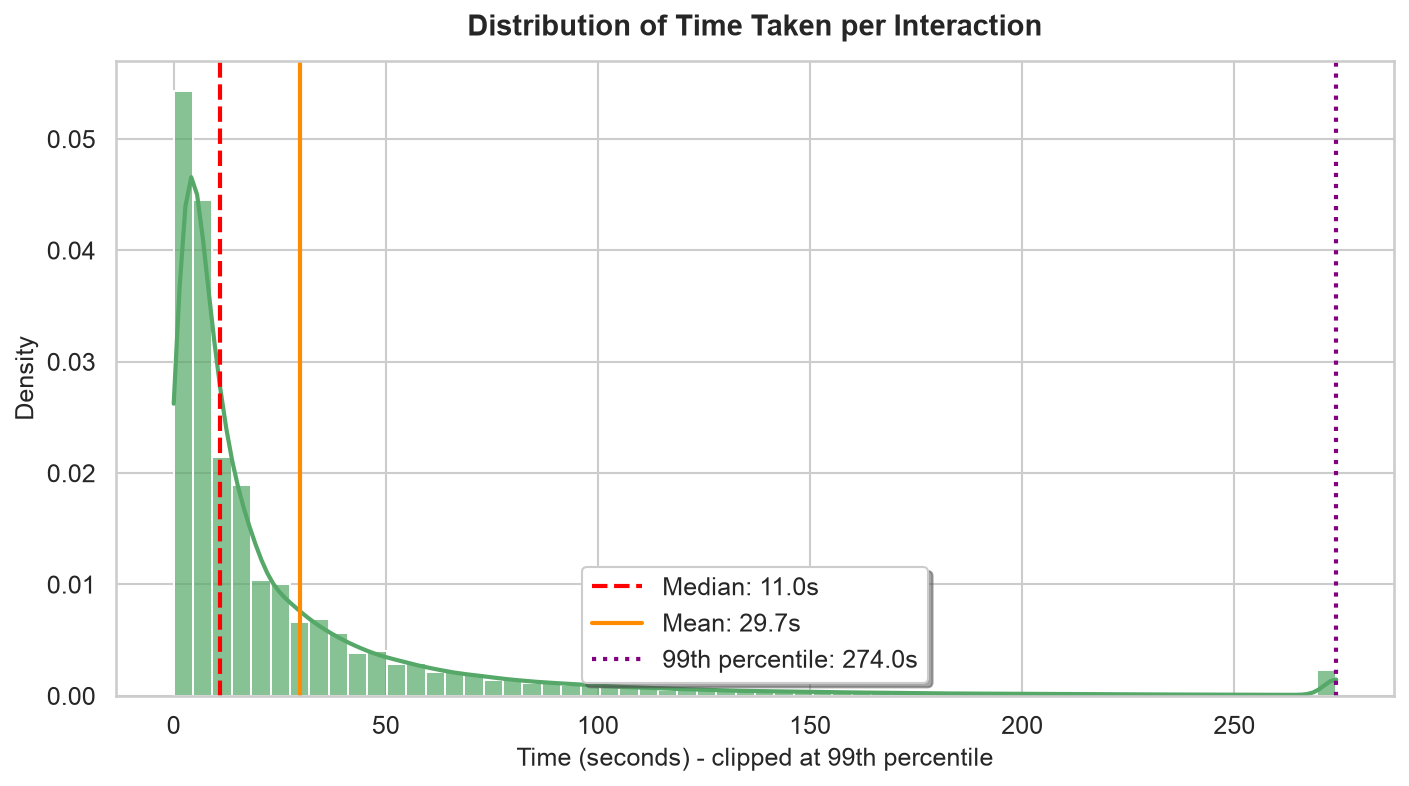

In [5]:
fig3_path = FIGURES_DIR / "03_time_taken_dist.png"
if fig3_path.exists():
    display(Image(filename=fig3_path, width=800))
else:
    print(f"⚠️ Không tìm thấy biểu đồ tại {fig3_path}")

### 🔍 Phân Tích Chi Tiết Biểu Đồ 03:
- **Trung vị (Median Time)**: **11.0 giây** — Đa số câu hỏi được trả lời trong khoảng từ 5 đến 30 giây.
- **Trung bình (Mean Time)**: **29.8 giây** (bị kéo cao bởi các giá trị ngoại lệ).
- **Bách phân vị thứ 99 (99th percentile)**: **274.0 giây** (~4.5 phút).
- **Ngoại lệ (Outliers)**: Có 7,810 lượt tương tác kéo dài >300s và 10 lượt kéo dài >3600s (max 9,999s).
- **Sử dụng gợi ý (Hint Usage)**: 51.31% số câu trả lời không dùng bất kỳ gợi ý nào (`hintCount = 0`). Số gợi ý trung bình là 1.22.

### 💡 Ý Nghĩa & Đề Xuất Cho Mô Hình Knowledge Tracing:
1. **Hiện tượng Treo máy / Phản hồi bất thường**: Các lượt tương tác có `timeTaken > 300s` thể hiện học sinh rời màn hình hoặc treo máy, không phản ánh đúng tư duy giải toán.
2. **Kỹ thuật Tiền xử lý (Feature Engineering)**:
   - **Capping/Clipping**: Giới hạn `timeTaken` ở mức tối đa **300 giây** (hoặc mốc 99th percentile = 274s).
   - **Log-transformation**: Sử dụng biến đổi `log1p(time_taken)` để chuyển phân phân bố lệch sang phân bố chuẩn.
   - **Time Interval Embedding**: Các mô hình hiện đại như **SAINT+** hay **KT-BERT** sử dụng mốc thời gian làm bài (Elapsed Time) và khoảng cách thời gian giữa 2 câu hỏi (Lag Time) dưới dạng Discretized Time Embeddings để tăng đáng kể độ chính xác dự đoán.

---
## 5. 📈 Phân Tích Độ Khó Kỹ Năng vs. Khối Lượng Tương Tác (Skill Difficulty vs. Volume)

Biểu đồ Scatter plot thể hiện mối quan hệ giữa Khối lượng tương tác của từng kỹ năng (Log scale trên trục X) và Tỷ lệ trả lời đúng trung bình của kỹ năng đó (Trục Y).

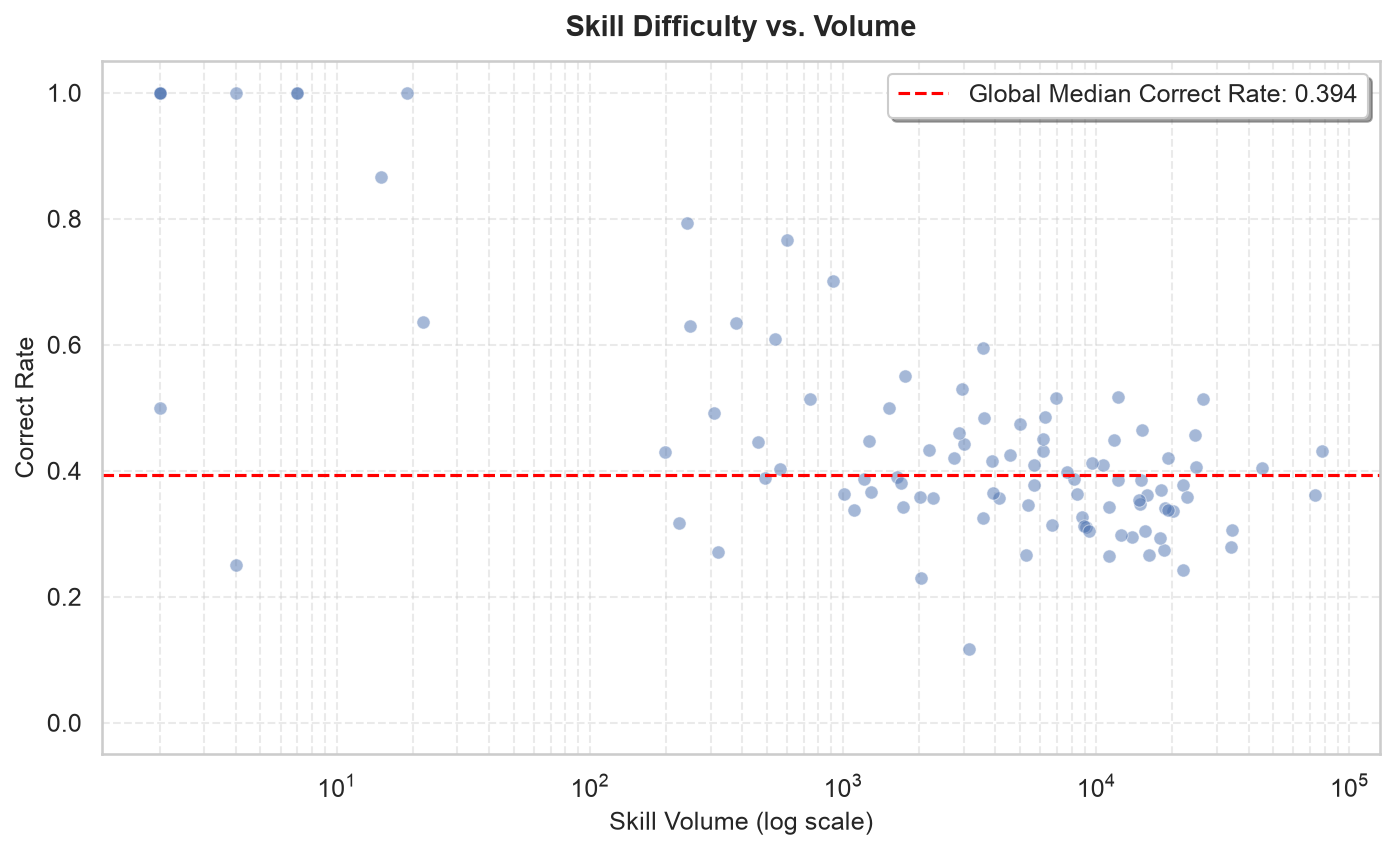

In [6]:
fig4_path = FIGURES_DIR / "04_skill_difficulty_scatter.png"
if fig4_path.exists():
    display(Image(filename=fig4_path, width=800))
else:
    print(f"⚠️ Không tìm thấy biểu đồ tại {fig4_path}")

### 🔍 Phân Tích Chi Tiết Biểu Đồ 04:
- **Tỷ lệ đúng tổng thể (Overall Correct Rate)**: **37.27%** (591,446 câu sai / 351,370 câu đúng).
- **Trung vị tỷ lệ đúng theo kỹ năng (Median Skill Accuracy)**: **38.67%**.
- **Kỹ năng khó nhất**:
  - `inequalities`: Tỷ lệ đúng chỉ **11.68%**
  - `measurement`: **22.93%**
  - `pythagorean-theorem`: **24.15%**
- **Kỹ năng dễ nhất**: Các kỹ năng ứng dụng đơn giản (`application: find slope in graph`, `application: multi-column addition`) đạt tỷ lệ đúng 100% (do số câu rất ít).
- **Hệ số tương quan (Correlation)**: **r = -0.2436** (tương quan âm nhẹ giữa khối lượng và tỷ lệ đúng).

### 💡 Ý Nghĩa & Đề Xuất Cho Mô Hình Knowledge Tracing:
1. **Độ thử thách của tập dữ liệu**: Tỷ lệ đúng 37.27% phản ánh tập dữ liệu tương đối khó đối với học sinh, là môi trường tốt để thử nghiệm khả năng phân biệt trình độ học sinh của các mô hình KT.
2. **Xu hướng tương quan âm**: Các kỹ năng có khối lượng tương tác lớn (như `pythagorean-theorem`, `equation-solving`) thường là các chủ đề nâng cao có độ khó cao, khiến học sinh phải làm lại nhiều lần.
3. **Skill Difficulty Embeddings / Rasch Parameter**: Cần đưa tham số độ khó của từng bài tập/kỹ năng vào nhúng của mô hình (tương tự lý thuyết bối cảnh câu hỏi IRT - Item Response Theory) để mô hình phân biệt được câu dễ và câu khó.

---
## 6. 💡 Tổng Kết & Kế Hoạch Tiền Xử Lý Dữ Liệu Cho Mô Hình Knowledge Tracing (KT Roadmap)

Dựa trên kết quả phân tích EDA toàn diện, các bước tiền xử lý dữ liệu tiếp theo cho bài toán Knowledge Tracing được khuyến nghị như sau:

| STT | Bước Tiền Xử Lý | Phương Pháp Thực Hiện | Mục Đích Cho Mô Hình KT |
|---|---|---|---|
| **1** | **Lọc dữ liệu rác & Trùng lặp** | Kiểm tra trùng lặp theo `(studentId, problemId, startTime, action_num)` | Đảm bảo tính nhất quán của chuỗi dữ liệu (Tập dữ liệu hiện tại 0% trùng lặp, 0% lỗi thời gian). |
| **2** | **Cắt & Phân đoạn chuỗi (`max_seq_len`)** | Thiết lập `max_seq_len = 200`. Với chuỗi > 200, dùng cửa sổ trượt (Sliding Window). | Tránh bùng nổ bộ nhớ GPU và giữ cho mô hình Transformer/RNN hoạt động hiệu quả. |
| **3** | **Xử lý nhãn kỹ năng (`skill`)** | Mã hóa 102 kỹ năng từ 1 đến 102. Nhãn `noskill` được gán mã 102 hoặc kết hợp với `problemId`. | Tạo ma trận nhúng (Embedding Matrix) cho Skill/Concept. |
| **4** | **Chuẩn hóa thời gian (`timeTaken`)** | Clip giá trị tối đa ở 300s, áp dụng `log1p(timeTaken)`, sau đó Discretize thành 100 bins. | Phản ánh thời gian suy nghĩ của học sinh (đầu vào cho SAINT+/KT-BERT). |
| **5** | **Chia tập dữ liệu Train/Val/Test** | Chia theo danh sách `studentId` (Student-level Split, tỷ lệ 80/10/10 hoặc 5-Fold Cross Validation). | Đảm bảo đánh giá chính xác khả năng tổng quát hóa của mô hình trên học sinh mới. |